In [ ]:
# 머신러닝 예측 실습 순서

# 2. 데이터 준비
# 3. 데이터 전처리
# 4. 데이터 분석
# 5. 머신러닝 학습/예측/평가
# 6. 머신러닝 성능향상 방법 찾기

In [2]:
import pandas as pd

df = pd.read_csv('SeoulBike/SeoulBikeData_1712.csv')
df.head(10)

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes
5,2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes
6,2017-12-01,181,6,-6.6,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
7,2017-12-01,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes
8,2017-12-01,930,8,-7.6,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
9,2017-12-01,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
df1 = pd.read_csv('SeoulBike/SeoulBikeData_1712.csv')
df2 = pd.read_csv('SeoulBike/SeoulBikeData_1801.csv')
df3 = pd.read_csv('SeoulBike/SeoulBikeData_1802.csv')

pd.concat([df1, df2, df3])

In [ ]:
import os

filelist = os.listdir('SeoulBike')
datafile = []
for file in filelist:
    if file.endswith(".csv"):
        datafile.append(file)

dfs = []
for file in datafile:
    # print('SeoulBike/' + file)
    # print(os.path.join('SeoulBike', file) )  
    filepath = os.path.join('SeoulBike', file)
    dfs.append(pd.read_csv(filepath))

pd.concat(dfs)

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2017-12-31,163,19,0.0,31,2.2,2000,-15.1,0.0,0.0,0.0,Winter,Holiday,Yes
740,2017-12-31,161,20,-1.0,32,0.9,2000,-15.6,0.0,0.0,0.0,Winter,Holiday,Yes
741,2017-12-31,179,21,-1.6,35,1.0,2000,-15.1,0.0,0.0,0.0,Winter,Holiday,Yes
742,2017-12-31,155,22,-2.1,36,1.7,2000,-15.2,0.0,0.0,0.0,Winter,Holiday,Yes


In [15]:
import os

folder_path = 'SeoulBike'

filelist = os.listdir(folder_path)
dfs = []
for file in filelist:
    if file.endswith(".csv"):
        filepath = os.path.join(folder_path, file)
        dfs.append(pd.read_csv(filepath))

bike = pd.concat(dfs, ignore_index=True)

In [16]:
bike.head()

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [17]:
bike.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(C)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [18]:
bike.describe()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [20]:
bike['Holiday'].value_counts() / 24

Holiday
No Holiday    347.0
Holiday        18.0
Name: count, dtype: float64

In [21]:
bike['Seasons'].value_counts()

Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

In [22]:
bike['Functioning Day'].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

In [24]:
bike[bike['Functioning Day'] == 'No']['Date'].unique()

<ArrowStringArray>
['2018-04-11', '2018-05-10', '2018-09-18', '2018-09-19', '2018-09-28',
 '2018-09-30', '2018-10-02', '2018-10-04', '2018-10-06', '2018-10-09',
 '2018-11-03', '2018-11-06', '2018-11-09']
Length: 13, dtype: str

In [26]:
# No 이면서 rent 0이 아닌경우
bike[ (bike['Functioning Day'] == 'No')  &  ( bike['Rented Bike Count'] > 0 ) ]
# Yes인데 rent 0인 경우
bike[ (bike['Functioning Day'] == 'Yes')  &  ( bike['Rented Bike Count'] == 0 ) ]

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day


In [27]:
bike[(bike['Rainfall(mm)'] != 0) & (bike['Snowfall (cm)'] != 0)]

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
120,2017-12-06,145,0,-2.8,77,0.0,331,-6.2,0.00,0.1,0.1,Winter,No Holiday,Yes
123,2017-12-06,78,3,-3.2,78,0.0,1808,-6.4,0.00,0.2,0.4,Winter,No Holiday,Yes
138,2017-12-06,204,18,1.7,90,1.0,66,0.2,0.00,0.3,0.3,Winter,No Holiday,Yes
141,2017-12-06,165,21,1.1,92,0.5,235,0.0,0.00,0.7,1.0,Winter,No Holiday,Yes
222,2017-12-10,9,6,-0.5,90,0.9,91,-1.9,0.00,2.5,2.7,Winter,No Holiday,Yes
225,2017-12-10,31,9,0.2,90,1.0,305,-1.2,0.00,1.6,4.3,Winter,No Holiday,Yes
411,2017-12-18,32,3,-5.3,76,1.0,767,-8.8,0.00,0.3,0.5,Winter,No Holiday,Yes
414,2017-12-18,45,6,-5.2,85,0.9,271,-7.3,0.00,0.4,1.3,Winter,No Holiday,Yes
417,2017-12-18,52,9,-4.3,89,1.0,59,-5.8,0.00,1.6,4.0,Winter,No Holiday,Yes
420,2017-12-18,62,12,-1.8,83,1.2,351,-4.3,0.09,1.1,5.1,Winter,No Holiday,Yes


In [33]:
# 날짜 변환
bike['Date'] = pd.to_datetime(bike['Date'])

In [32]:
pd.to_datetime(pd.Series(['11/08/26']), format='%d/%m/%y')

0   2026-08-11
dtype: datetime64[us]

In [37]:
bike['Date'].dt.day_of_week

0       4
1       4
2       4
3       4
4       4
       ..
8755    4
8756    4
8757    4
8758    4
8759    4
Name: Date, Length: 8760, dtype: int32

In [43]:
bike['Week'] = bike['Date'].dt.day_name()

In [42]:
bike['Date'].dt.quarter

0       4
1       4
2       4
3       4
4       4
       ..
8755    4
8756    4
8757    4
8758    4
8759    4
Name: Date, Length: 8760, dtype: int32

In [44]:
bike['Week'].unique()

<ArrowStringArray>
['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Length: 7, dtype: str

In [45]:
bike['Holiday'].unique()

<ArrowStringArray>
['No Holiday', 'Holiday']
Length: 2, dtype: str

In [ ]:
bike['Week'].isin(['Saturday', 'Sunday']) # 주말조건
bike['Week'].notin(['Saturday', 'Sunday']) # 평일조건

In [ ]:
bike.iloc[0] # == row

Date                        2017-12-01 00:00:00
Rented Bike Count                           254
Hour                                          0
Temperature(C)                             -5.2
Humidity(%)                                  37
Wind speed (m/s)                            2.2
Visibility (10m)                           2000
Dew point temperature(C)                  -17.6
Solar Radiation (MJ/m2)                     0.0
Rainfall(mm)                                0.0
Snowfall (cm)                               0.0
Seasons                                  Winter
Holiday                              No Holiday
Functioning Day                             Yes
Week                                     Friday
Name: 0, dtype: object

In [49]:
def check_day(row):
    if row['Week'] in ['Saturday', 'Sunday'] or row['Holiday'] == 'Holiday':
        return 'Yes'
    else:
        return 'No'

bike['Day off'] = bike.apply(check_day, axis = 1)

In [ ]:
bike['Rented Bike Count']

<Axes: xlabel='Date', ylabel='Rented Bike Count'>

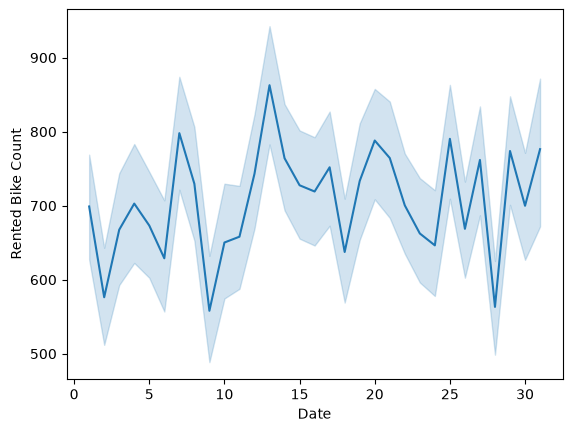

In [59]:
import seaborn as sns

sns.lineplot(x = bike['Date'].dt.day, y = bike['Rented Bike Count'], 
             estimator= 'mean' )

In [60]:
# 종속변수 독립변수 중점으로 분석
bike.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Week', 'Day off'],
      dtype='str')

In [66]:
import matplotlib.pyplot as plt

<Axes: xlabel='Week', ylabel='Rented Bike Count'>

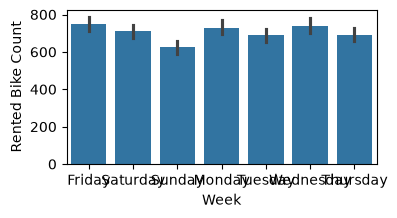

In [67]:
bike['Day off'].value_counts()
plt.figure(figsize = (4,2))
sns.barplot(x = 'Week', y = 'Rented Bike Count', data = bike)

In [69]:
bike.corr(numeric_only=True)

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Rented Bike Count,1.000000,0.410257,0.538558,-0.199780,0.121108,0.199280,0.379788,0.261837,-0.123074,-0.141804
Hour,0.410257,1.000000,0.124114,-0.241644,0.285197,0.098753,0.003054,0.145131,0.008715,-0.021516
Temperature(C),0.538558,0.124114,1.000000,0.159371,-0.036252,0.034794,0.912798,0.353505,0.050282,-0.218405
Humidity(%),-0.199780,-0.241644,0.159371,1.000000,-0.336683,-0.543090,0.536894,-0.461919,0.236397,0.108183
Wind speed (m/s),0.121108,0.285197,-0.036252,-0.336683,1.000000,0.171507,-0.176486,0.332274,-0.019674,-0.003554
Visibility (10m),0.199280,0.098753,0.034794,-0.543090,0.171507,1.000000,-0.176630,0.149738,-0.167629,-0.121695
Dew point temperature(C),0.379788,0.003054,0.912798,0.536894,-0.176486,-0.176630,1.000000,0.094381,0.125597,-0.150887
Solar Radiation (MJ/m2),0.261837,0.145131,0.353505,-0.461919,0.332274,0.149738,0.094381,1.000000,-0.074290,-0.072301
Rainfall(mm),-0.123074,0.008715,0.050282,0.236397,-0.019674,-0.167629,0.125597,-0.074290,1.000000,0.008500
Snowfall (cm),-0.141804,-0.021516,-0.218405,0.108183,-0.003554,-0.121695,-0.150887,-0.072301,0.008500,1.000000


In [ ]:
# 분석 이어서

# 삭제 : 날짜, 이슬점, Functioning Day, rent값이 0인 데이터, Holiday, week

# onehot, scaler 진행

# 일반화 검증

# 모델 선택(linear, ridge, randomforest)

# 학/예/평

# 성능향상(gridsearch, 전처리 다르게(시간대 범주 묶기), 다항회귀 등)

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

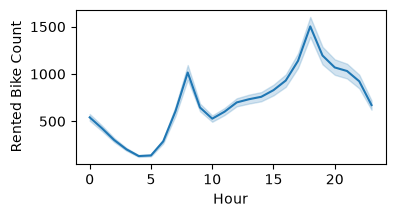

In [76]:
plt.figure(figsize = (4,2))
sns.lineplot(x = 'Hour', y = 'Rented Bike Count', data = bike)

In [77]:
bike.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Week', 'Day off'],
      dtype='str')

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

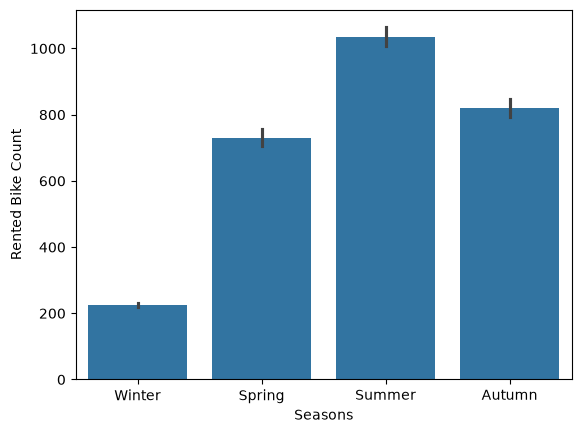

In [78]:
sns.barplot(x = 'Seasons', y = 'Rented Bike Count', data = bike)

In [79]:
bike.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Week', 'Day off'],
      dtype='str')

In [80]:
# 삭제 : 날짜, 이슬점, Functioning Day, rent값이 0인 데이터, Holiday, week

bike = bike[bike['Rented Bike Count'] > 0]

X = bike.drop(['Date', 'Dew point temperature(C)', 'Functioning Day', 
              'Holiday', 'Week', 'Rented Bike Count'], axis = 1)
y = bike['Rented Bike Count']

In [86]:
X.columns

Index(['Hour', 'Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)',
       'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Seasons', 'Day off'],
      dtype='str')

In [ ]:
# OneHot, Scaler
from sklearn.preprocessing import OneHotEncoder, StandardScaler

oh_enc = OneHotEncoder(sparse_output = False)
oh_res = oh_enc.fit_transform(X[['Hour', 'Seasons', 'Day off']])
oh_X = pd.DataFrame(oh_res, columns= oh_enc.get_feature_names_out() )

st_scaler = StandardScaler()
num_col = ['Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)',
            'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
            'Snowfall (cm)']
sc_res = st_scaler.fit_transform(X[num_col])
sc_X = pd.DataFrame(sc_res, columns = num_col)

X_scaled = pd.concat([sc_X, oh_X], axis = 1)

In [ ]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor

X_rand = X_scaled.sample(frac = 1, random_state = 0)
y_rand = y.sample(frac = 1, random_state = 0)

dt_reg = DecisionTreeRegressor()
cross_val_score(dt_reg, X_rand, y_rand, scoring = 'neg_mean_squared_error', cv = 5)

array([-74538.45067927, -77902.48966332, -66003.09746013, -73126.252215  ,
       -70124.36030715])

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, 
                                                    random_state = 0)
print(X_train.shape, X_test.shape, y_train.shape)

(6772, 37) (1693, 37) (6772,)


In [99]:
# 모델 선택(linear, ridge, randomforest)
# 학/예/평
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

378.58069260427027
0.6353286302424679


In [100]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 0.1)
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

378.57177010860147
0.6353458193936199


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train)
pred = rf_reg.predict(X_test)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

208.16144423820683
0.8897482909725221


In [110]:

# 성능향상(gridsearch, 전처리 다르게(시간대 범주 묶기), 다항회귀 등)

from sklearn.model_selection import GridSearchCV

rf_reg = RandomForestRegressor(n_estimators=200)
parameters = {
              'max_depth' : [None, 3, 5, 7], 
              'min_samples_split' : [2, 5, 9], 
              'min_samples_leaf' : [1, 5, 10], 
              'random_state' : [0]}
grid = GridSearchCV(rf_reg, param_grid=parameters, scoring = 'neg_root_mean_squared_error', cv = 5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...stimators=200)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...], 'random_state': [0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable 

In [114]:
model = grid.best_estimator_
pred = model.predict(X_test)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

208.35536166780207
0.8895427804229361


In [122]:
# X_train, X_test를 다항회귀 > linear, ridge
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 3, include_bias = False)
poly.fit(X_train)
X_train_poly = poly.transform(X_train)
X_test_poly = poly.transform(X_test)
print(X_train_poly.shape)

(6772, 9879)


In [123]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_poly, y_train)
pred = lr_reg.predict(X_test_poly)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

2193.1023377261986
-11.237777169747707


In [129]:
ridge = Ridge(alpha=50)
ridge.fit(X_train_poly, y_train)
pred = ridge.predict(X_test_poly)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

225.63340136468955
0.8704636886195058


In [133]:
# 2차 poly 데이터
poly = PolynomialFeatures(degree = 2, include_bias = False)
poly.fit(X_train)
X_train_poly = poly.transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=10)
ridge.fit(X_train_poly, y_train)
pred = ridge.predict(X_test_poly)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

241.86746542132963
0.8511531485032287


In [134]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [ ]:
col = X.columns

In [138]:
X.iloc[200]

Hour                            8
Temperature(C)               -5.4
Humidity(%)                    56
Wind speed (m/s)              0.7
Visibility (10m)             1940
Solar Radiation (MJ/m2)      0.01
Rainfall(mm)                  0.0
Snowfall (cm)                 0.0
Seasons                    Winter
Day off                       Yes
Name: 200, dtype: object

In [142]:
hour = 8 # int(input('시간대 : '))
temp = -5.4 # float(input('온도 : '))
humid = 56 # int(input('습도 : '))
wind = 0.7 # float(input('풍속 : '))
visi = 1940 # int(input('가시거리(10m) : '))
solar = 0.01 # float(input('태양열 : '))
rain = 0.0 # float(input('강수량 : '))
snow = 0.0 # float(input('적설량 : '))
season = 'Winter' # input('계절(Winter/Autumn/Spring/Summer) : ')
day = 'Yes' # input('주말여부(Yes/No) : ')

pred_data = pd.DataFrame([[hour, temp, humid, wind, visi, 
                          solar, rain, snow, season, day]], columns = col)

pred_oh = oh_enc.transform(pred_data[['Hour', 'Seasons', 'Day off']])
oh_pred = pd.DataFrame(pred_oh, columns= oh_enc.get_feature_names_out() )

pred_sc = st_scaler.transform(pred_data[num_col])
sc_pred = pd.DataFrame(pred_sc, columns = num_col)

pred_data = pd.concat([sc_pred, oh_pred], axis = 1)

In [145]:
model.predict(pred_data), y.iloc[200]

(array([114.84]), np.int64(222))